# 5. POŁĄCZENIA RESIDUALNE I TRANSFER LEARNING

## 0.Cel listy

Celem tej listy zadań jest zapoznanie się z:

* gotowymi architekturami sieci neuronowych,
* ideą **połączeń residualnych (skip connections)**,
* oraz praktycznym wykorzystaniem **transfer learningu** w zadaniach z zakresu wizji komputerowej.

W poprzednich listach budowaliśmy sieci neuronowe „od zera”, projektując architekturę warstwa po warstwie. W praktyce jednak **bardzo rzadko trenuje się modele od podstaw**- zamiast tego korzysta się z gotowych, sprawdzonych architektur i wag wytrenowanych na dużych zbiorach danych, dotrenowując model pod konretne zadanie.



W tej liście:

* skupimy się na architekturach z rodziny **ResNet**,
* zobaczymy, czym są i po co stosuje się połączenia residualne,
* porównamy różne strategie treningu:

  * inferencję na modelu pretrenowanym,
  * trenowanie tylko ostatniej warstwy,
  * fine-tuning całego modelu,
  * trening od zera.



Do wykonania zadania rekomendowane jest użycie zbioru **CIFAR** z torchvision z powodu, że jest to trudniejszy zbiór i powinno być na nim lepiej widać, różne schematy uczenia, ale jeśli będzie występowal problem z zasobami obliczeniowymi można wykonać zadanie na zbiorze **FashionMNIST**




## 1.Połączenia residualne- teoria

### Problem zanikającego i wybuchającego gradientu

Podczas trenowania sieci neuronowej używamy algorytmu **propagacji wstecznej (backpropagation)**, w którym gradient funkcji straty jest przekazywany od wyjścia sieci do jej początkowych warstw.

Dla bardzo głębokich sieci pojawiają się dwa poważne problemy:

###  Zanikający gradient (vanishing gradient)

* gradient w kolejnych warstwach staje się coraz mniejszy,
* pierwsze warstwy uczą się bardzo wolno lub wcale,
* sieć nie wykorzystuje swojej głębokości.

###  Wybuchający gradient (exploding gradient)

* gradient w kolejnych warstwach gwałtownie rośnie,
* prowadzi to do niestabilnego treningu,
* wagi mogą przyjmować bardzo duże wartości (NaN).

Oba problemy są szczególnie widoczne w **głębokich sieciach** (dziesiątki lub setki warstw).



## Skąd bierze się ten problem? (intuicyczna matematyka)

Rozważmy bardzo uproszczony przypadek sieci składającej się z wielu warstw:

$$
h_l = f(W_l h_{l-1})
$$


Podczas propagacji wstecznej gradient względem wcześniejszych warstw zawiera **iloczyn pochodnych**:

$$
\frac{\partial L}{\partial h_0}
$$

$$
\frac{\partial L}{\partial h_L}
\cdot
\prod_{l=1}^{L}
\frac{\partial h_l}{\partial h_{l-1}}
$$

Jeśli:

* pochodne są **mniejsze od 1** - iloczyn dąży do zera → *zanik gradientu*
* pochodne są **większe od 1** - iloczyn rośnie wykładniczo → *wybuch gradientu*

Nawet przy użyciu funkcji aktywacji takich jak ReLU oraz technik typu Batch Normalization, problem **nie znika całkowicie** dla bardzo głębokich sieci.

#### Dodatkowe materiały:
- [Vanishing AND Exploding Gradient Problem Explained](https://www.youtube.com/watch?v=CzNFuL_5uig)
- [kod + wizaulizacje problemu](https://www.geeksforgeeks.org/deep-learning/vanishing-and-exploding-gradients-problems-in-deep-learning/)




### Intuicja stojąca za połączeniem residualnym

Zastanówmy się nad prostym przypadkiem.

Załóżmy, że idealna transformacja pomiędzy wejściem a wyjściem pewnej części sieci to:
$$
H(x) = x
$$

Czyli: **warstwy nic nie zmieniają**.

Dla klasycznej sieci neuronowej oznacza to, że musi ona nauczyć się funkcji identyczności, co w praktyce **nie jest trywialne** dla wielu warstw nieliniowych.



Zamiast uczyć się funkcji:
$$
H(x)
$$

możemy uczyć się **residuum**:
$$
F(x) = H(x) - x
$$

Jeśli najlepszym rozwiązaniem jest identyczność, to:
$$
F(x) = 0
$$

Uczenie się „zera” lub „małej poprawki” jest:

* łatwiejsze,
* stabilniejsze,
* szybsze dla optymalizacji gradientowej.



### Wzór matematyczny połączenia residualnego

Połączenie residualne definiujemy jako:

$$
y = F(x) + x
$$

gdzie:

* x - wejście do bloku,
* F(x) - klasyczna transformacja (np. Conv -> ReLU -> Conv),
* y - wyjście bloku residualnego.

### Co to zmienia?

* gradient może przepływać **bezpośrednio** przez składnik (+x),
* nawet jeśli F(x) jest trudne do nauczenia,
* sieć zawsze ma „bezpieczną ścieżkę” dla propagacji gradientu.


## Najważniejsze konsekwencje połączeń residualnych

* umożliwiają trenowanie **bardzo głębokich sieci**,
* zmniejszają problem degradacji jakości,
* stabilizują propagację gradientu,
* sprawiają, że dodawanie kolejnych warstw **nie pogarsza wyników**.

Poniżej obrazek przedstawiający schemat działania tego połączenia.


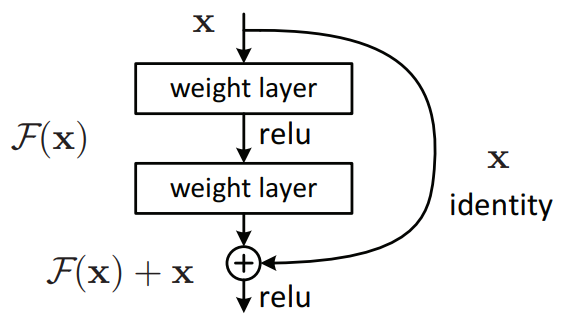

DODATKOWE MATERIAŁY:
- [ORGINALNY PAPER](https://arxiv.org/pdf/1512.03385) - Gorąco polecam, ponieważ autorzy bardzo klarownie postawili hipotezę, ekperyment weryfikujący, oraz wnioski. Jest to wzór pod względem tego jak publikacja powinna wyglądać.
- [ORGINALNY PAPER OMÓWIENIE NA YT](https://www.youtube.com/watch?v=GWt6Fu05voI)
- [SZCZEGÓŁOWE WYJAŚNIENIE](https://mbrenndoerfer.com/writing/residual-connections-deep-neural-networks-resnet)

## 2. ZADANIE 1. IMPLEMENTACJA MODUŁU RESIDUALNEGO
Jako zadanie rozgrzewkowe należy na podstawie schematu powyżej dokończyć implementację modułu residualnego, przepuścić przez niego "dummy input" i uruchomić testy w celu weryfikacji poprawności. Celem jest zobaczenie przykładowej implementacji takiego bloku.

**UWAGA**: Symbol "+" na schemacie odpowada zwykłemu **dodaniu tensorów** a nie konkatenacji.

In [ ]:
#Dummy wejście (NIE NALEŻY MODYFIKOWAĆ KOMÓRKI)

import torch
# Ustalmy powtarzalność
torch.manual_seed(0)

# Dummy batch obrazów: (batch_size, channels, height, width)
B, C, H, W = 4, 16, 32, 32
x = torch.randn(B, C, H, W)
print("x shape:", x.shape)


x shape: torch.Size([4, 16, 32, 32])


In [ ]:
# Moduł ResidualBlock z brakującym kodem (TODO)

import torch.nn as nn
import torch.nn.functional as F

class ResidualBlock(nn.Module):
    """
    Blok residualny zgodny ze schematem:
        x -> Conv -> ReLU -> Conv -> ( + x ) -> ReLU
    Zakładamy, że wejście i wyjście mają te same wymiary (C, H, W).
    """
    def __init__(self, channels: int, kernel_size: int = 3):
        super().__init__()
        padding = kernel_size // 2  # żeby zachować H,W dla kernel=3

        self.conv1 = nn.Conv2d(channels, channels, kernel_size=kernel_size, padding=padding, bias=True)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=kernel_size, padding=padding, bias=True)
        self.relu = nn.ReLU(inplace=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # TODO 1: policz F(x) = Conv -> ReLU -> Conv
        # TODO 2: dodaj skip connection: out = F(x) + x
        # TODO 3: zastosuj ReLU na końcu i zwróć wynik

        # ----- START TODO -----
        fx = self.conv2(self.relu(self.conv1(x)))
        out = fx + x
        out = nn.ReLU()(out)
        return out
        # ----- END TODO -----


In [ ]:
# Testy (NIE NALEŻY MODYFIKOWAĆ KOMÓRKI)

def zero_out_conv(conv: nn.Conv2d):
    with torch.no_grad():
        conv.weight.zero_()
        if conv.bias is not None:
            conv.bias.zero_()

# 1) Inicjalizacja i test wymiarów
block = ResidualBlock(channels=C)

y = block(x)
print("y shape:", y.shape)

assert y.shape == x.shape, f"Shape mismatch: got {y.shape}, expected {x.shape}"
print("Shape test passed")

# 2) Test semantyczny: jeśli ustawimy wagi obu conv na 0 -> F(x)=0
#    wtedy y = ReLU(x) (bo na końcu jest ReLU po dodaniu).
zero_out_conv(block.conv1)
zero_out_conv(block.conv2)

y2 = block(x)
expected = torch.relu(x)

max_diff = (y2 - expected).abs().max().item()
print("max |y2 - ReLU(x)| =", max_diff)

assert torch.allclose(y2, expected, atol=1e-6), "Residual behavior test failed"
print("Residual behavior test passed (F(x)=0 => y=ReLU(x))")

# 3) Test gradientu: sprawdzamy czy gradient przepływa do x
x_req = x.clone().detach().requires_grad_(True)
y3 = block(x_req)
loss = y3.sum()
loss.backward()

grad_norm = x_req.grad.norm().item()
print("x grad norm:", grad_norm)

assert grad_norm > 0, "Gradient flow test failed (grad_norm should be > 0)"
print("Gradient flow test passed")


y shape: torch.Size([4, 16, 32, 32])
Shape test passed
max |y2 - ReLU(x)| = 0.0
Residual behavior test passed (F(x)=0 => y=ReLU(x))
x grad norm: 180.78993225097656
Gradient flow test passed


## 3. PRETRENOWANE MODELE I TRANSFER LEARNING


#### Dlaczego nie zawsze trenujemy model od zera?

W zadaniach z zakresu wizji komputerowej obrazy- niezależnie od konkretnego problemu- mają **wspólną strukturę**.

W głębokich sieciach konwolucyjnych:

* **początkowe warstwy** uczą się bardzo ogólnych cech:

  * krawędzie,
  * narożniki,
  * proste tekstury,
* **środkowe warstwy** łączą je w bardziej złożone wzorce:

  * fragmenty obiektów,
  * charakterystyczne kształty,
* **końcowe warstwy** są najbardziej specyficzne dla zadania:

  * konkretne klasy,
  * decyzje klasyfikacyjne.

Oznacza to, że wiedza zdobyta przez model na jednym zadaniu (np. klasyfikacja milionów obrazów) może być **ponownie wykorzystana** w innym, podobnym zadaniu.

Dlatego w praktyce:

* **nie musimy uczyć modelu wszystkiego od zera**,
* możemy wykorzystać wcześniej wyuczone wagi,
* oszczędzamy czas, dane i zasoby obliczeniowe.


DODATKOWE MATERIAŁY:
- [Co "widzą" CNN-y w kolejnych warstwach](https://arxiv.org/pdf/1311.2901)


## Podstawowe pojęcia: pretraining i transfer learning

**Model pretrenowany (pretrained model)**

* jego wagi zostały wyuczone na dużym zbiorze danych,
* zwykle na **ogólnym zadaniu** (np. klasyfikacja obrazów w przypadku computer vision, chodź nie musi tak być),
* Często mówi się o takim modelu w naszym rozwiązaniu jako **Backbone**, ponieważ on odpowada za większość "wiedzy" w naszym modelu.

W przypadku wizji komputerowej bardzo często modele są pretrenowane na zbiorze ImageNet, który zawiera miliony obrazów i tysiące klas.

Przykład:
Resnet18 z biblioteki torchvision wraz z wagami z ImageNeta.



**Zamrażanie wag**
- Polega na tym że część lub całość modelu (wag) nie przekazuje gradientu dalej, co oznacza że te konretne wagi nie będą się dalej optymalizowały w trakcie trenigu
- W torchu odbywa się między innymi poprzez
  * `requires_grad = False`,
- Stosowane kiedy chcemy pozostawić wagi modelu i zmodyfikować tylko jego fragment (najczęściej ostatnią warstwę klasyfikujacą lub pare ostatnich warst)


**Transfer learning**
Polega na wykorzystaniu modelu pretrenowanego oraz dostosowaniu go do **zadania docelowego**.

Może to przyjmować różne formy, w zależności od ilości danych i podobieństwa zadań. Jest to szeroki temat, ale najkrócej tłumacząc strategie jakie są nabardziej znane to:
- **linear probing**- Zamrożenie całości modelu i wytrenowaniu jedynie ostatniej warstwy klasyfikującej pod nasze zadanie .
- **partial fine-tuning**Zamrożenie większości modelu, ale dotrenowujemy też ostatnie warstwy/blocki w naszym backbonie . Ile dokładnie odmrażamy a ile zostawiamy jest bardzo mocno zależne od naszego zadania, ilości danych  oraz doświadczenia.
- **Full fine-tuning** Odmrożenie całego modelu i dotrenowanie go w całości naszych danych


DODATKOWE MATERIAŁY:
- [linear probing vs finetuning](https://www.phontron.com/class/anlp2022/assets/slides/anlp-10-raghunathan.pdf)
- [how to freez model in torch](https://python.plainenglish.io/how-to-freeze-model-weights-in-pytorch-for-transfer-learning-step-by-step-tutorial-a533a58051ef)



## Architektura ResNet i modele dostępne w torchvision

**ResNet (Residual Network)** to rodzina głębokich sieci konwolucyjnych opartych na:

* blokach residualnych,
* połączeniach typu skip connection,
* bardzo dużej głębokości (dziesiątki lub setki warstw).

Kluczowa idea:

* sieć uczy się **residuum** zamiast pełnej transformacji,
* co umożliwia stabilny trening bardzo głębokich modeli.


Biblioteka `torchvision.models` udostępnia gotowe implementacje ResNetów, m.in.:

* `resnet18`
* `resnet34`
* `resnet50`
* `resnet101`
* `resnet152`

Różnią się one:

* liczbą warstw,
* liczbą parametrów,
* złożonością bloków residualnych.

Modele te:

* mogą być inicjalizowane losowo,
* lub z wagami **pretrenowanymi na ImageNet**.


DODATKOWE MATERIAŁY:
- [torchvision resnet18](https://docs.pytorch.org/vision/main/models/generated/torchvision.models.resnet18.html)

## 4. ZADANIE 2- transfer learning



Celem zadania jest praktyczne zapoznanie się z różnymi strategiami wykorzystania **modeli pretrenowanych** na przykładzie architektury **ResNet** oraz porównanie ich zachowania podczas treningu.


### 1. Wybór i analiza architektury

1. Wybierz **jeden model z rodziny ResNet**:

   * `ResNet18` lub `ResNet34`
     (większe modele nie są wymagane do tego zadania).

2. Załaduj model **z wagami pretrenowanymi na ImageNet**.

3. Wyświetl architekturę modelu (`print(model)` lub podobnie) i:

   * zidentyfikuj część konwolucyjną (backbone),
   * zlokalizuj ostatnią warstwę klasyfikacyjną,
   * zwróć uwagę na strukturę bloków residualnych.

Celem tego punktu jest **zrozumienie, z jakich elementów składa się model**, a nie tylko jego użycie jako „czarnej skrzynki”.


### 2. Przygotowanie danych i wyjścia modelu

1. Wykorzystaj zbiór danych wskazany we wprowadzeniu (np. CIFAR / FashionMNIST).
2. Dostosuj dane wejściowe do wymagań modelu:

   * odpowiedni rozmiar obrazu,
   * liczba kanałów,
   * normalizacja.

3. Zastąp **ostatnią warstwę liniową** modelu tak, aby liczba neuronów wyjściowych odpowiadała liczbie klas w zadaniu docelowym.


### 3. Zestaw eksperymentów

Na tym samym zbiorze danych przeprowadź **następujące eksperymenty**, zachowując spójne ustawienia (batch size, optimizer, itp.).

- Eksperyment 1 - Linear probing

  * Zamroź wszystkie warstwy modelu poza ostatnią warstwą liniową.
  * Trenuj **tylko nową warstwę klasyfikacyjną**.
  * Model pełni rolę ekstraktora cech.


- Eksperyment 2 - Partial fine-tuning

  * Zamroź większość modelu,
  * Odmroź:

    * ostatni blok ResNeta,
    * oraz warstwę klasyfikacyjną.
  * Trenuj tylko te elementy.


- Eksperyment 3 - Full fine-tuning

  * Użyj modelu pretrenowanego,
  * Odmroź **wszystkie warstwy**,
  * Dotrenuj cały model na zadaniu docelowym.
  * Trening **nie musi być długi** - wystarczy kilka lub kilkanaście epok.


- Eksperyment 4 - Trening od zera

  * Załaduj ten sam model ResNet, ale **bez wag pretrenowanych**.
  * Wytrenuj go od zera na tym samym zbiorze danych.
  * Wystarczy kilka pierwszych epok - celem jest obserwacja przebiegu uczenia.


### UWAGI

* Stosuj dobre praktyki treningowe z poprzednich list.
* **Zawsze śledź `train loss` oraz `validation loss`** - w tym zadaniu jest to szczególnie istotne.
* Monitoruj metryki na zbiorze treningowym, walidacyjnym i testowym.
* Porównuj podejścia między sobą:

  * wartości strat,
  * metryki walidacyjne i testowe,
  * szybkość oraz stabilność zbieżności.
* Zwróć uwagę na różnice w przebiegu krzywych uczenia między ekperymentami.
* Przy full fine-tuningu i treningu od zera **wystarczy kilka / kilkanaście epok** - nie jest wymagane doprowadzenie treningu do pełnej konwergencji.
* Celem zadania jest **zrozumienie dynamiki uczenia i wpływu pretrenowania**, a nie maksymalizacja końcowej dokładności.
* Przy dotrenowywaniu, często stosuje się mniejszy lr niż przy treningu od zera.


In [ ]:
# TODO- WPISZ SWÓJ KOD

In [ ]:
from torchvision.models import resnet34

In [ ]:
model = resnet34(weights='DEFAULT')

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 189MB/s]


# Analiza pobranego modelu

Konwolucja: Stanowi pierwszą warstwę modelu oraz zawartość każdego bloku rezydualnego BasicBlock. Blok ten stanowi klasę modułu `torchvision.models.resnet` i jego funkcja `forward()` przypomina rysunek bloku rezydualnego z części początkowej tego notatnika + batch norm po każdej konwolucji:

    def forward(self, x: Tensor) -> Tensor:
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)

        return out


Klasyfikacja: warstwa klasyfikacyjna znajduje się na końcu modelu. Jest to warstwa w pełni połączona (fully connected), przyjmuje 512 parametrów, natomiast zwraca ich 1000. Odpowiada to liczbie klas ze zbioru ImageNet.

struktura: Odpowiada temu co zauważyć można po prawej stronie rysunku 3 w artykule. Model składa się z 6 części: na początku wykonywana jest na obrazie konwolucja dużym filtrem (7x7). Następnie wynik przechodzi przez kolejne 4 bloki sequential, każdy z warstwami konwolucyjnymi o innej, zwiększającej się liczbie kanałów wyjściowych, a na końcu warstwa klasyfikacyjna zwraca pewną wartość dla każdej z 1000 klas.

In [ ]:
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

Pobranie datasetu Cifar10. Pozostawiam normalizację jak w poprzednim notatniku. Obrazy w tym datasecie składają się z 3 kanałów, co jest zgodne z pierwszą warstwą konwolucyjną resnet34.

In [ ]:
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

testset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

100%|██████████| 170M/170M [00:02<00:00, 76.8MB/s]


In [ ]:
trainset[0][0].shape

torch.Size([3, 32, 32])

Wizualizacja przykładowych obrazów.

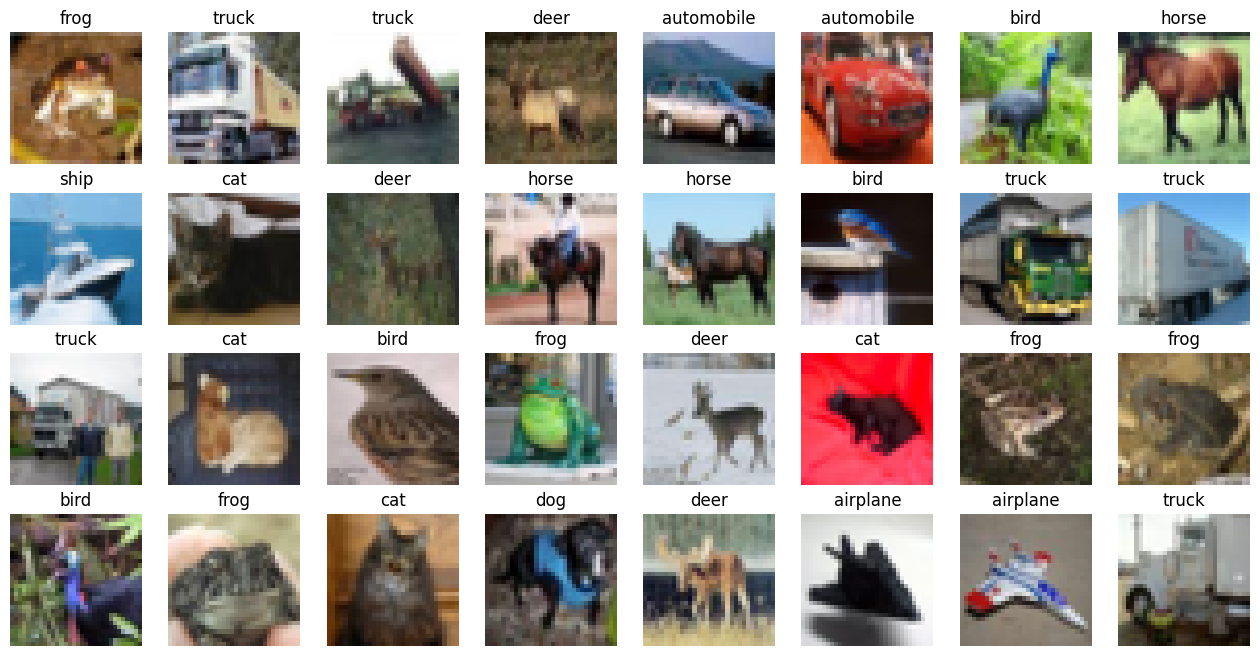

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

target_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
plt.figure(figsize=(16, 8))
for i in range(32):
  plt.subplot(4, 8, i+1)
  plt.title(target_names[trainset[i][1]])
  img = trainset[i][0].permute(1, 2, 0).numpy()
  img = img * 0.5 + 0.5
  plt.imshow(img)
  plt.axis('off')

Połączenie z dyskiem, gdzie umieszczony jest kod treningowy i do wizualizacji.

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import math
import sys
import torch
import torch.nn as nn
sys.path.insert(0, "/content/drive/MyDrive/wdrozenie/modules")
import Helper_module as m # moduł z kodem do treningu i wizualizacji

Utworzenie loaderów.

In [ ]:
batch_size = 128
train_size = int(0.8 * len(trainset))
train_data, validation_data = torch.utils.data.random_split(trainset, [train_size, len(trainset) - train_size])

trainloader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
validationloader = torch.utils.data.DataLoader(validation_data, batch_size=batch_size, num_workers=2, pin_memory=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, num_workers=2, pin_memory=True)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

Funkcja do przygotowania modelu do kolejnych eksperymentów. Pozwala ona na odmrażanie wybranych warstw.

In [ ]:
def prepare_model_for_training(model, modules_to_unfreeze_names=None):
  in_ftrs = model.fc.in_features
  model.fc = nn.Linear(in_ftrs, 10) # ustawienie wyjścia warstwy klasyfikacyjnej modelu na 10 klas

  for param in model.parameters(): # domyślnie zamrozenie wszystkich warstw
    param.requires_grad = False

  if modules_to_unfreeze_names:
    for module_name in modules_to_unfreeze_names: # odmrozenie tylko wskazanych w parametrze
      module = getattr(model, module_name, None)
      for param in module.parameters():
        param.requires_grad = True
  return model

# 1 - Linear probing
Podczas eksperymentów zainspirowałem się trochę artykułem i podczas treningu redukowałem `lr` w następujący sposób, zawsze gdy strata na zbiorze walidacyjnym przestała się zmniejszać:

    ...
    lr_wait += 1
    if lr_wait >= self.lr_patience:
      self.optimizer.param_groups[0]['lr'] /= 2
      lr_wait = 0
      print(f"lr reduced to {self.optimizer.param_groups[0]['lr']}")
    ...

  1%|          | 1/100 [00:27<44:58, 27.26s/it]

epoch: 1, train loss: 1.651, validation loss: 1.690


  3%|▎         | 3/100 [01:19<42:29, 26.29s/it]

epoch: 3, train loss: 1.499, validation loss: 1.559


  5%|▌         | 5/100 [02:08<39:38, 25.04s/it]

...

 69%|██████▉   | 69/100 [27:35<12:06, 23.44s/it]

epoch: 69, train loss: 1.387, validation loss: 1.496


 69%|██████▉   | 69/100 [27:58<12:34, 24.33s/it]

lr reduced to 1.953125e-06
Early stopping at epoch 70


test loss: 1.460


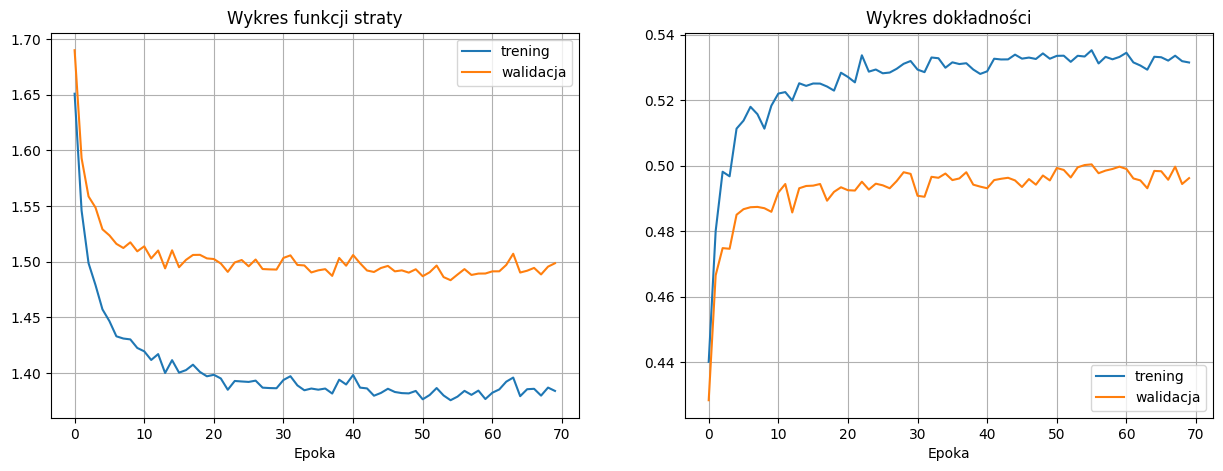

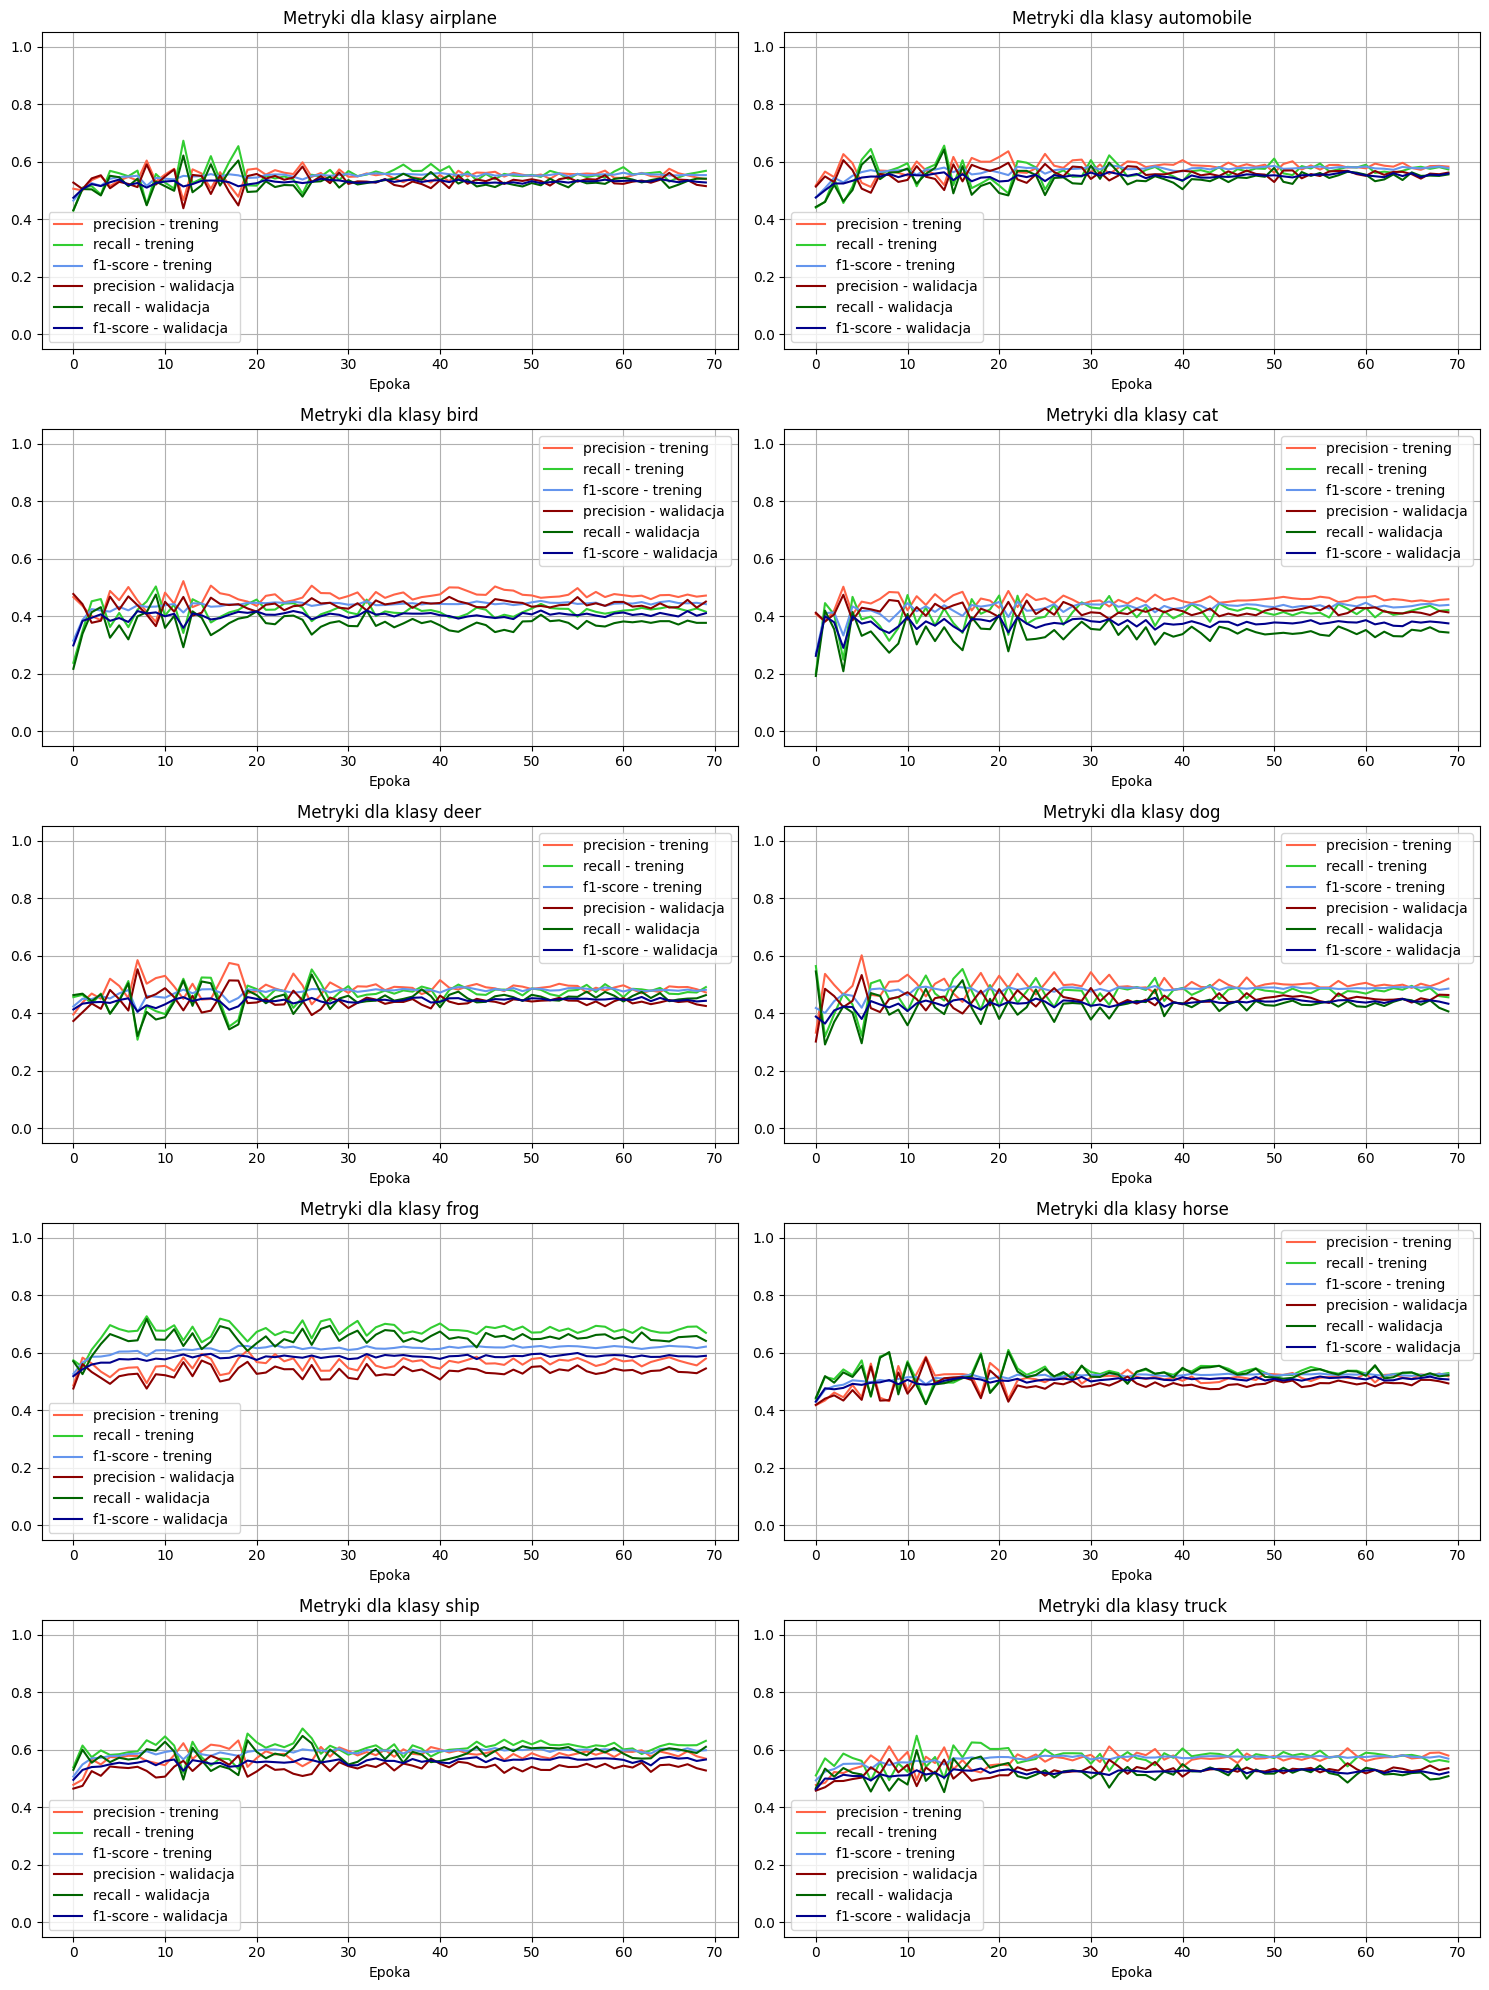

In [ ]:
epochs_num = 100
model = resnet34(weights='DEFAULT')
model = prepare_model_for_training(model, modules_to_unfreeze_names=['fc']) # odmrozenie wawrstwy klasyfikacyjnej
                                                                                  # zmniejszone lr podczas dotrenowania
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.0005, weight_decay=0.0001)

trainer = m.TrainingClass(model, device, nn.CrossEntropyLoss(), optimizer, early_stopping=True, patience=15)
ts_loss1, tr_losses1, val_losses1, tr_metrics1, val_metrics1, tr_accuracies1, val_accuracies1 = trainer.training_loop(epochs_num, "resnet-1", trainloader, validationloader, testloader)

m.create_loss_and_accuracy_plot(tr_losses1, val_losses1, tr_accuracies1, val_accuracies1)
m.create_metrics_plot(tr_metrics1, val_metrics1)

W outpucie zauważyć można że `lr` zmniejszane było aż 8 razy podczas treningu, aczkolwiek dało to niewielką poprawę, gdyż począwszy od epoki 20 strata prawie się nie zmniejszała. Ponadto dokładność modelu na zbiorze walidacyjnym podczas treningu ledwo osiągnęła 50%.

#2 - Partial fine-tuning

  1%|          | 1/100 [00:39<1:04:59, 39.39s/it]

epoch: 1, train loss: 0.741, validation loss: 0.969


  3%|▎         | 3/100 [01:45<56:01, 34.65s/it]

epoch: 3, train loss: 0.326, validation loss: 0.959


  5%|▌         | 5/100 [02:52<53:32, 33.82s/it]

...

 17%|█▋        | 17/100 [09:18<44:37, 32.26s/it]

epoch: 17, train loss: 0.010, validation loss: 1.750


 17%|█▋        | 17/100 [09:50<48:04, 34.75s/it]

lr reduced to 6.25e-05
Early stopping at epoch 18


test loss: 0.950


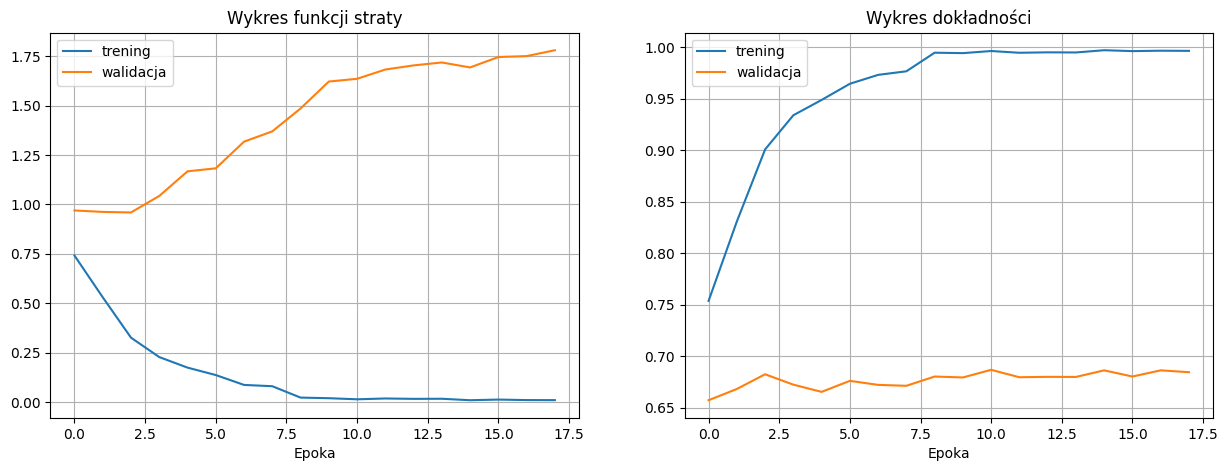

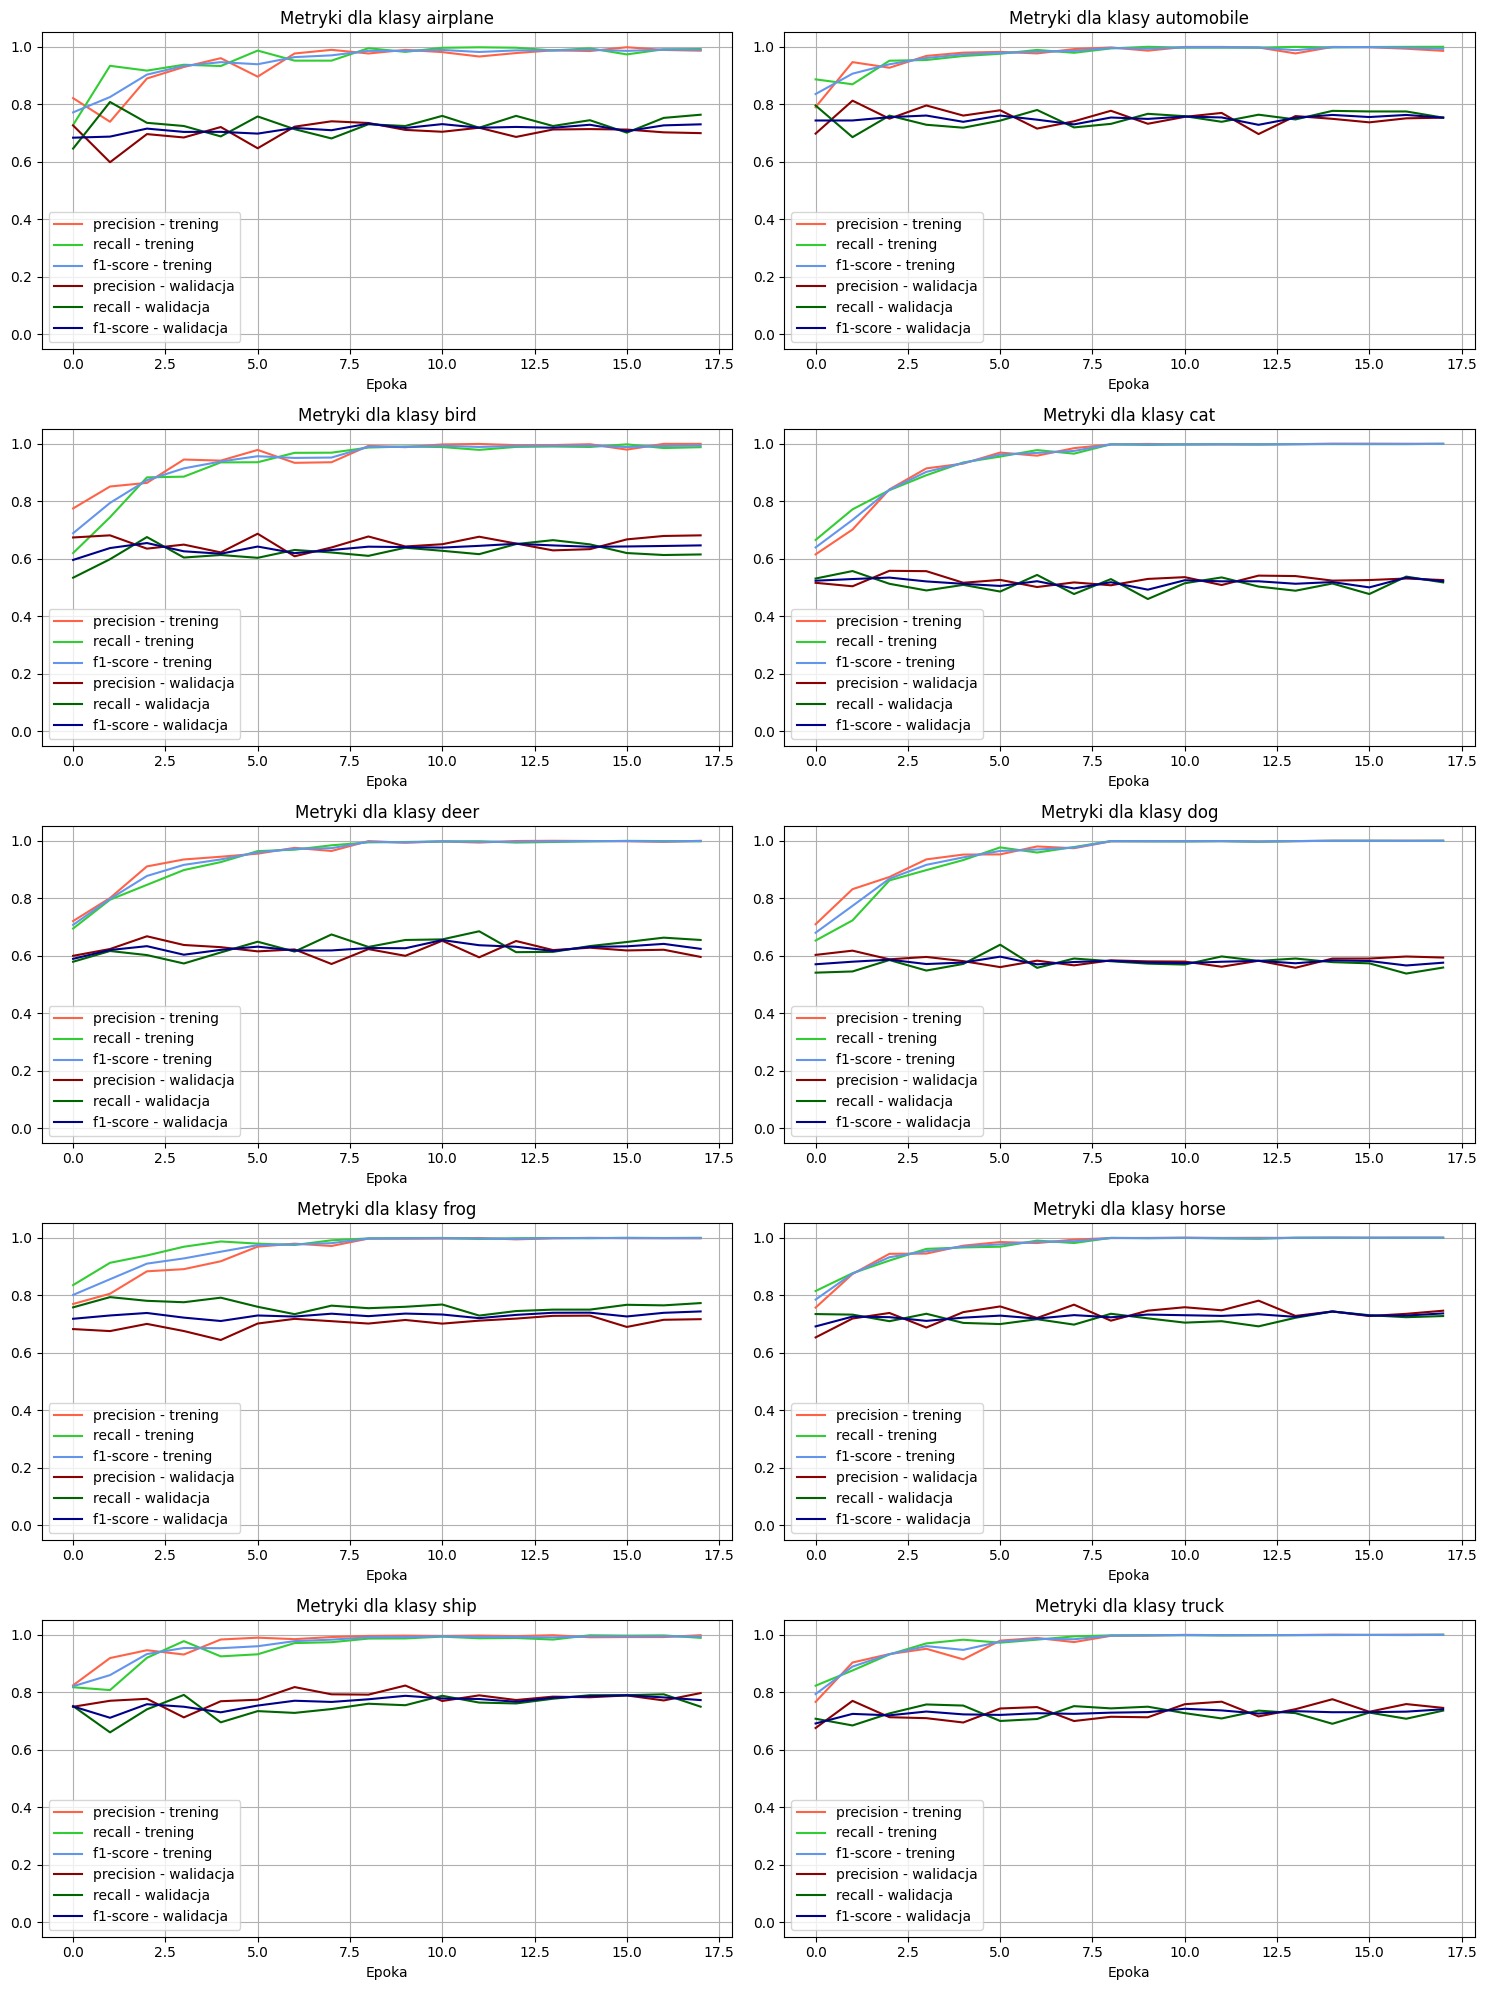

In [ ]:
epochs_num = 100
model = resnet34(weights='DEFAULT')                                 # odmrozenie warstwy klasyfikacyjnej oraz ostatniego bloku sequential
model = prepare_model_for_training(model, modules_to_unfreeze_names=['fc', 'layer4'])
                                                                                  # zmniejszone lr podczas dotrenowania
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.0005, weight_decay=0.0001)

trainer = m.TrainingClass(model, device, nn.CrossEntropyLoss(), optimizer, early_stopping=True, patience=15)
ts_loss2, tr_losses2, val_losses2, tr_metrics2, val_metrics2, tr_accuracies2, val_accuracies2 = trainer.training_loop(epochs_num, "resnet-2", trainloader, validationloader, testloader)

m.create_loss_and_accuracy_plot(tr_losses2, val_losses2, tr_accuracies2, val_accuracies2)
m.create_metrics_plot(tr_metrics2, val_metrics2)

Większa możliwość manipulowania parametrami modelu przełożyła się na szybką poprawę wyników. Problemem jednak okazał się tutaj overfitting. Przy częściowo odmrożonym modelu na zbiorze treningowym uzyskano dokładność rzędu 99% podczas gdy dla zbioru walidacyjnego pozostała poniżej 70%.

#3 - Full fine-tuning

  4%|▍         | 1/25 [00:46<18:40, 46.67s/it]

epoch: 1, train loss: 0.499, validation loss: 0.675


 12%|█▏        | 3/25 [02:09<15:36, 42.55s/it]

epoch: 3, train loss: 0.215, validation loss: 0.568


 20%|██        | 5/25 [03:31<13:49, 41.47s/it]

...

 68%|██████▊   | 17/25 [11:33<05:23, 40.39s/it]

epoch: 17, train loss: 0.002, validation loss: 0.941


 68%|██████▊   | 17/25 [12:13<05:45, 43.17s/it]

lr reduced to 6.25e-05
Early stopping at epoch 18


test loss: 0.566


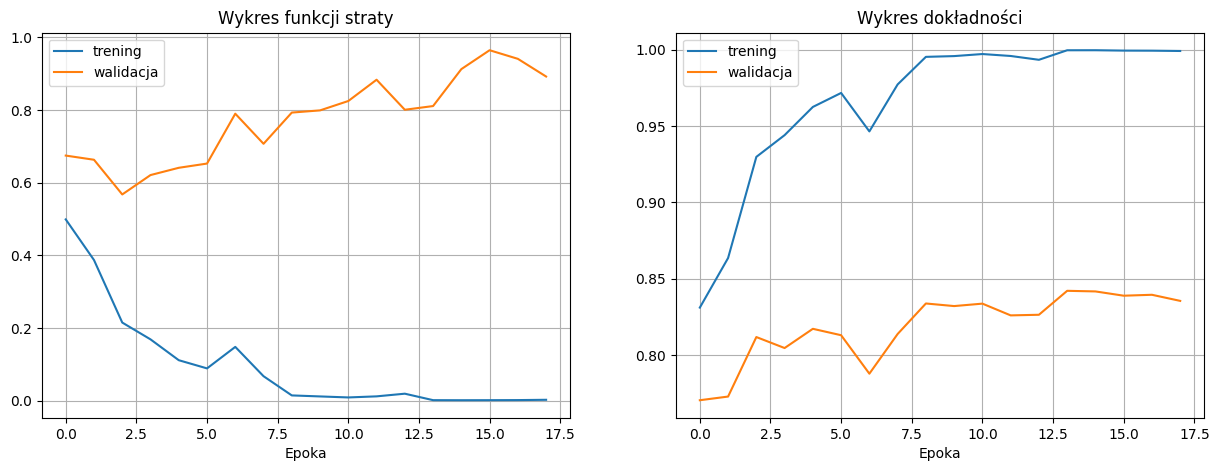

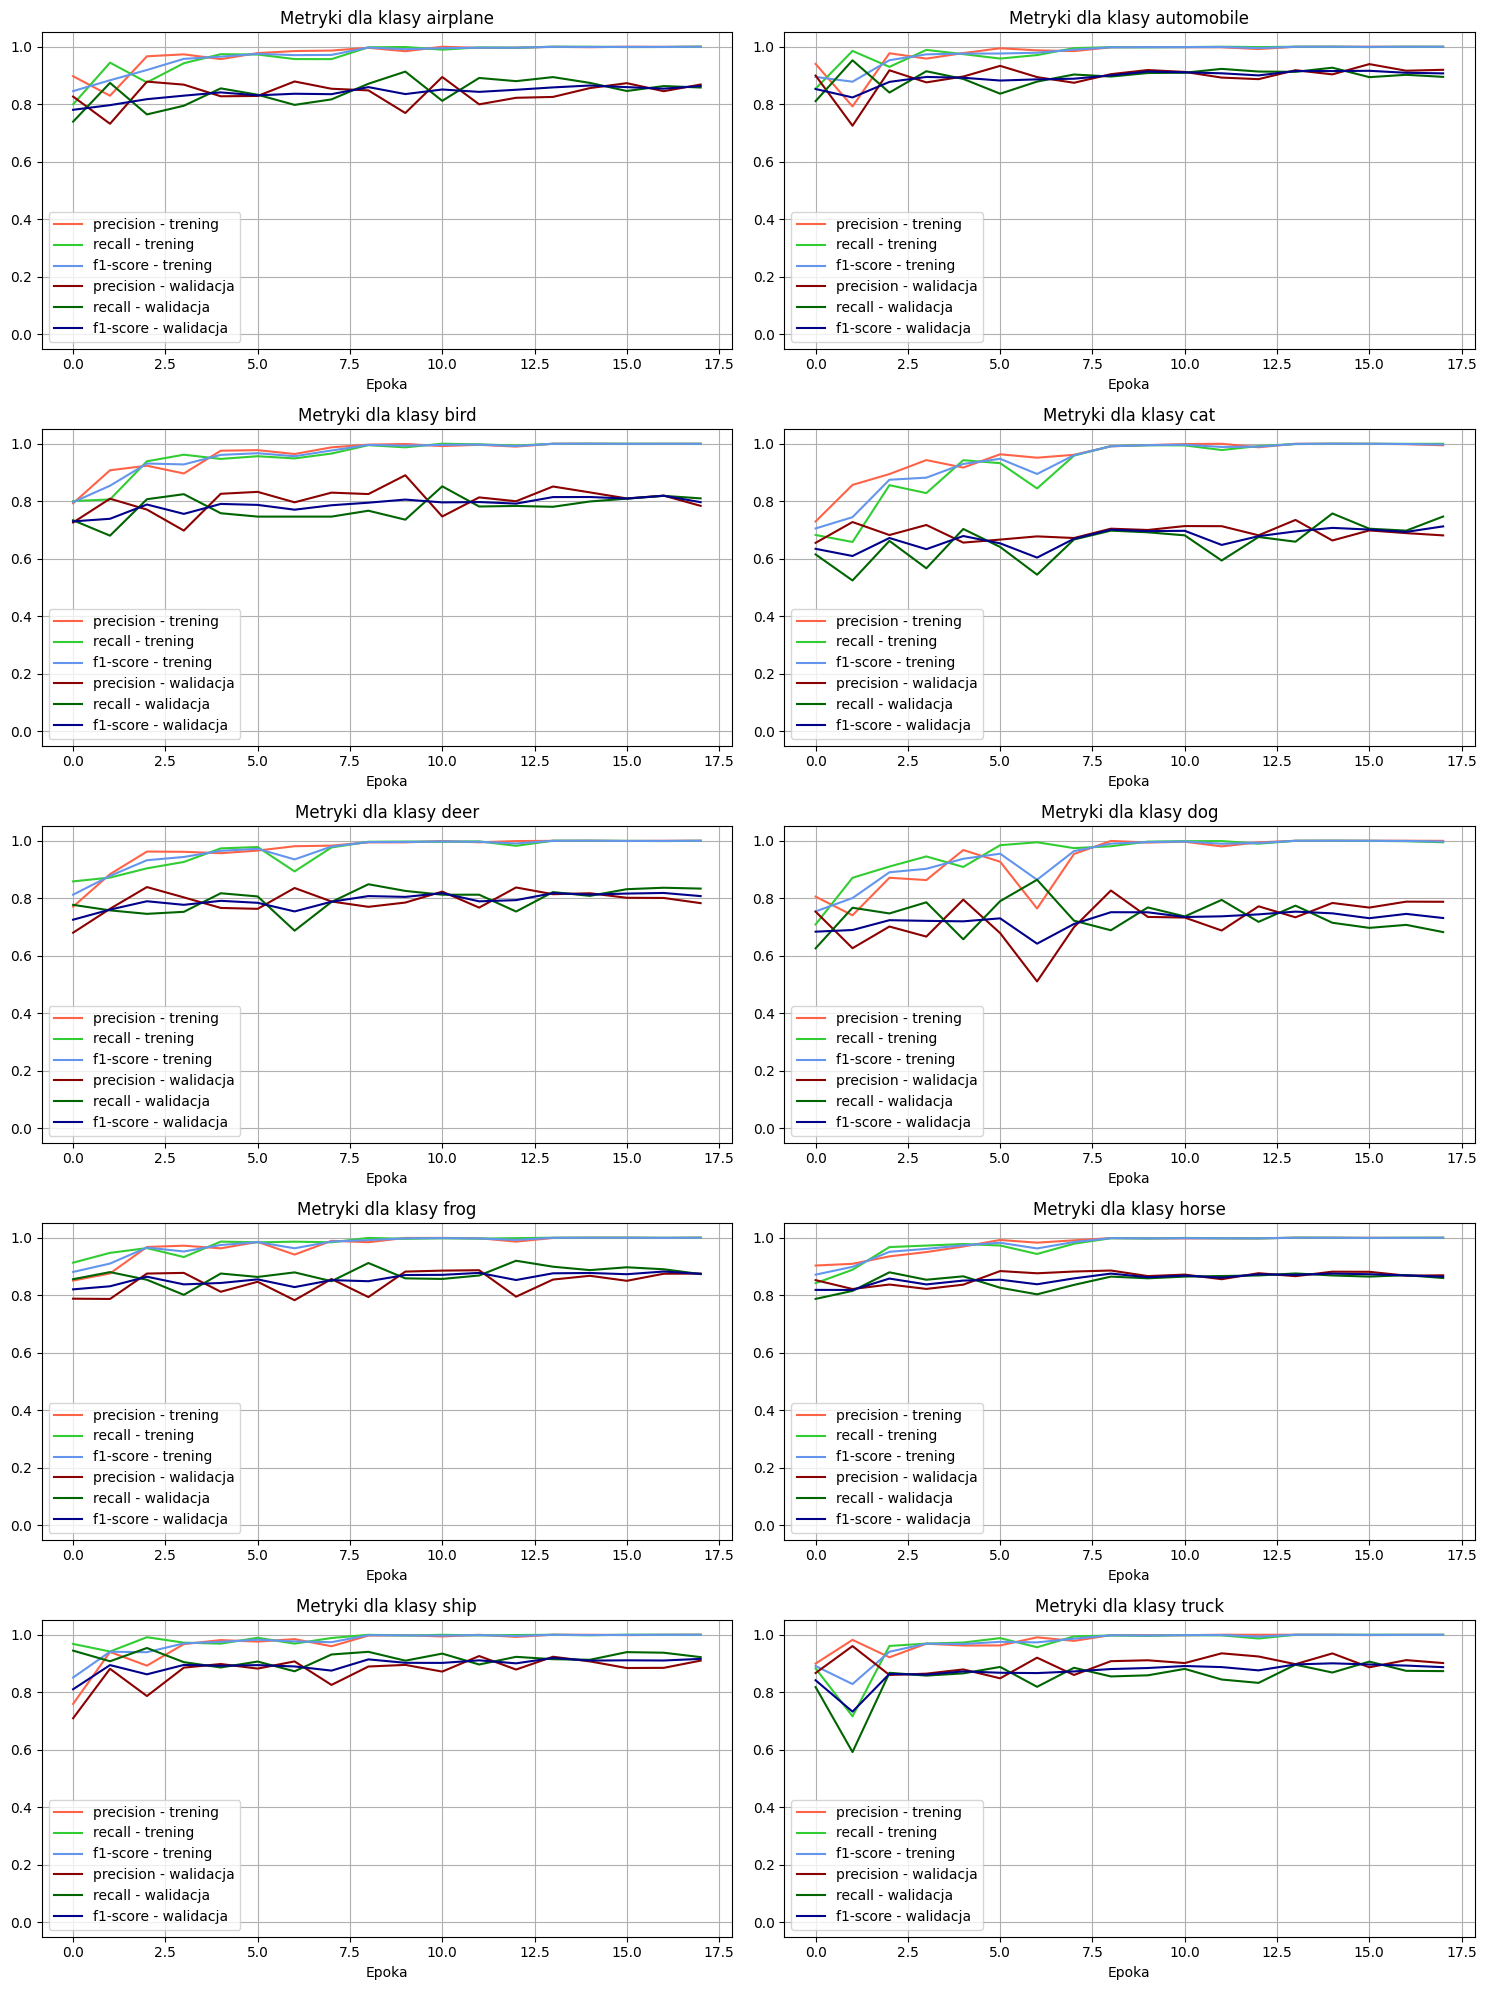

In [ ]:
epochs_num = 25
model = resnet34(weights='DEFAULT')                                   # odmrozenie wszystkich parametrów modelu
model = prepare_model_for_training(model, modules_to_unfreeze_names=[name for name, _ in model.named_children()])
                                                                                  # zmniejszone lr podczas dotrenowania
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.0005, weight_decay=0.0001)

trainer = m.TrainingClass(model, device, nn.CrossEntropyLoss(), optimizer, early_stopping=True, patience=15)
ts_loss3, tr_losses3, val_losses3, tr_metrics3, val_metrics3, tr_accuracies3, val_accuracies3 = trainer.training_loop(epochs_num, "resnet-3", trainloader, validationloader, testloader)

m.create_loss_and_accuracy_plot(tr_losses3, val_losses3, tr_accuracies3, val_accuracies3)
m.create_metrics_plot(tr_metrics3, val_metrics3)

Pełna kontrola nad parametrami modelu pozwoliła na jeszcze większą poprawę wyników. Choć overfitting wciąż występuje to wyniki na zbiorze walidacyjnym nie pogarszają się w znaczący sposób, a dokładność przeważnie rosła podczas całego treningu.

#4 - Trening od zera

  7%|▋         | 1/15 [00:46<10:56, 46.91s/it]

epoch: 1, train loss: 1.255, validation loss: 1.343


 20%|██        | 3/15 [02:09<08:30, 42.51s/it]

epoch: 3, train loss: 0.802, validation loss: 0.980


 33%|███▎      | 5/15 [03:32<06:58, 41.82s/it]

...

 87%|████████▋ | 13/15 [09:03<01:26, 43.27s/it]

epoch: 13, train loss: 0.057, validation loss: 1.137


100%|██████████| 15/15 [10:25<00:00, 41.72s/it]

epoch: 15, train loss: 0.042, validation loss: 1.183


test loss: 0.858


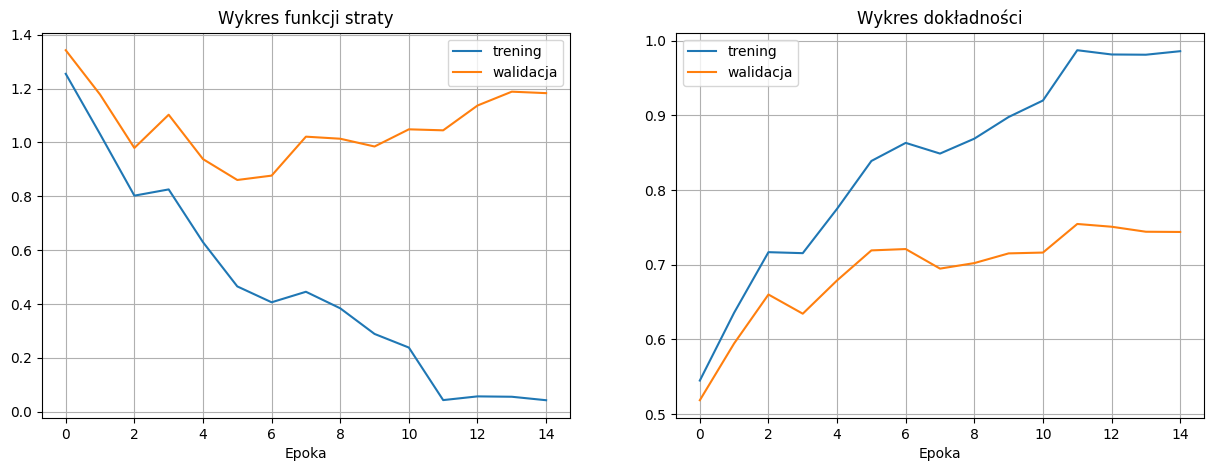

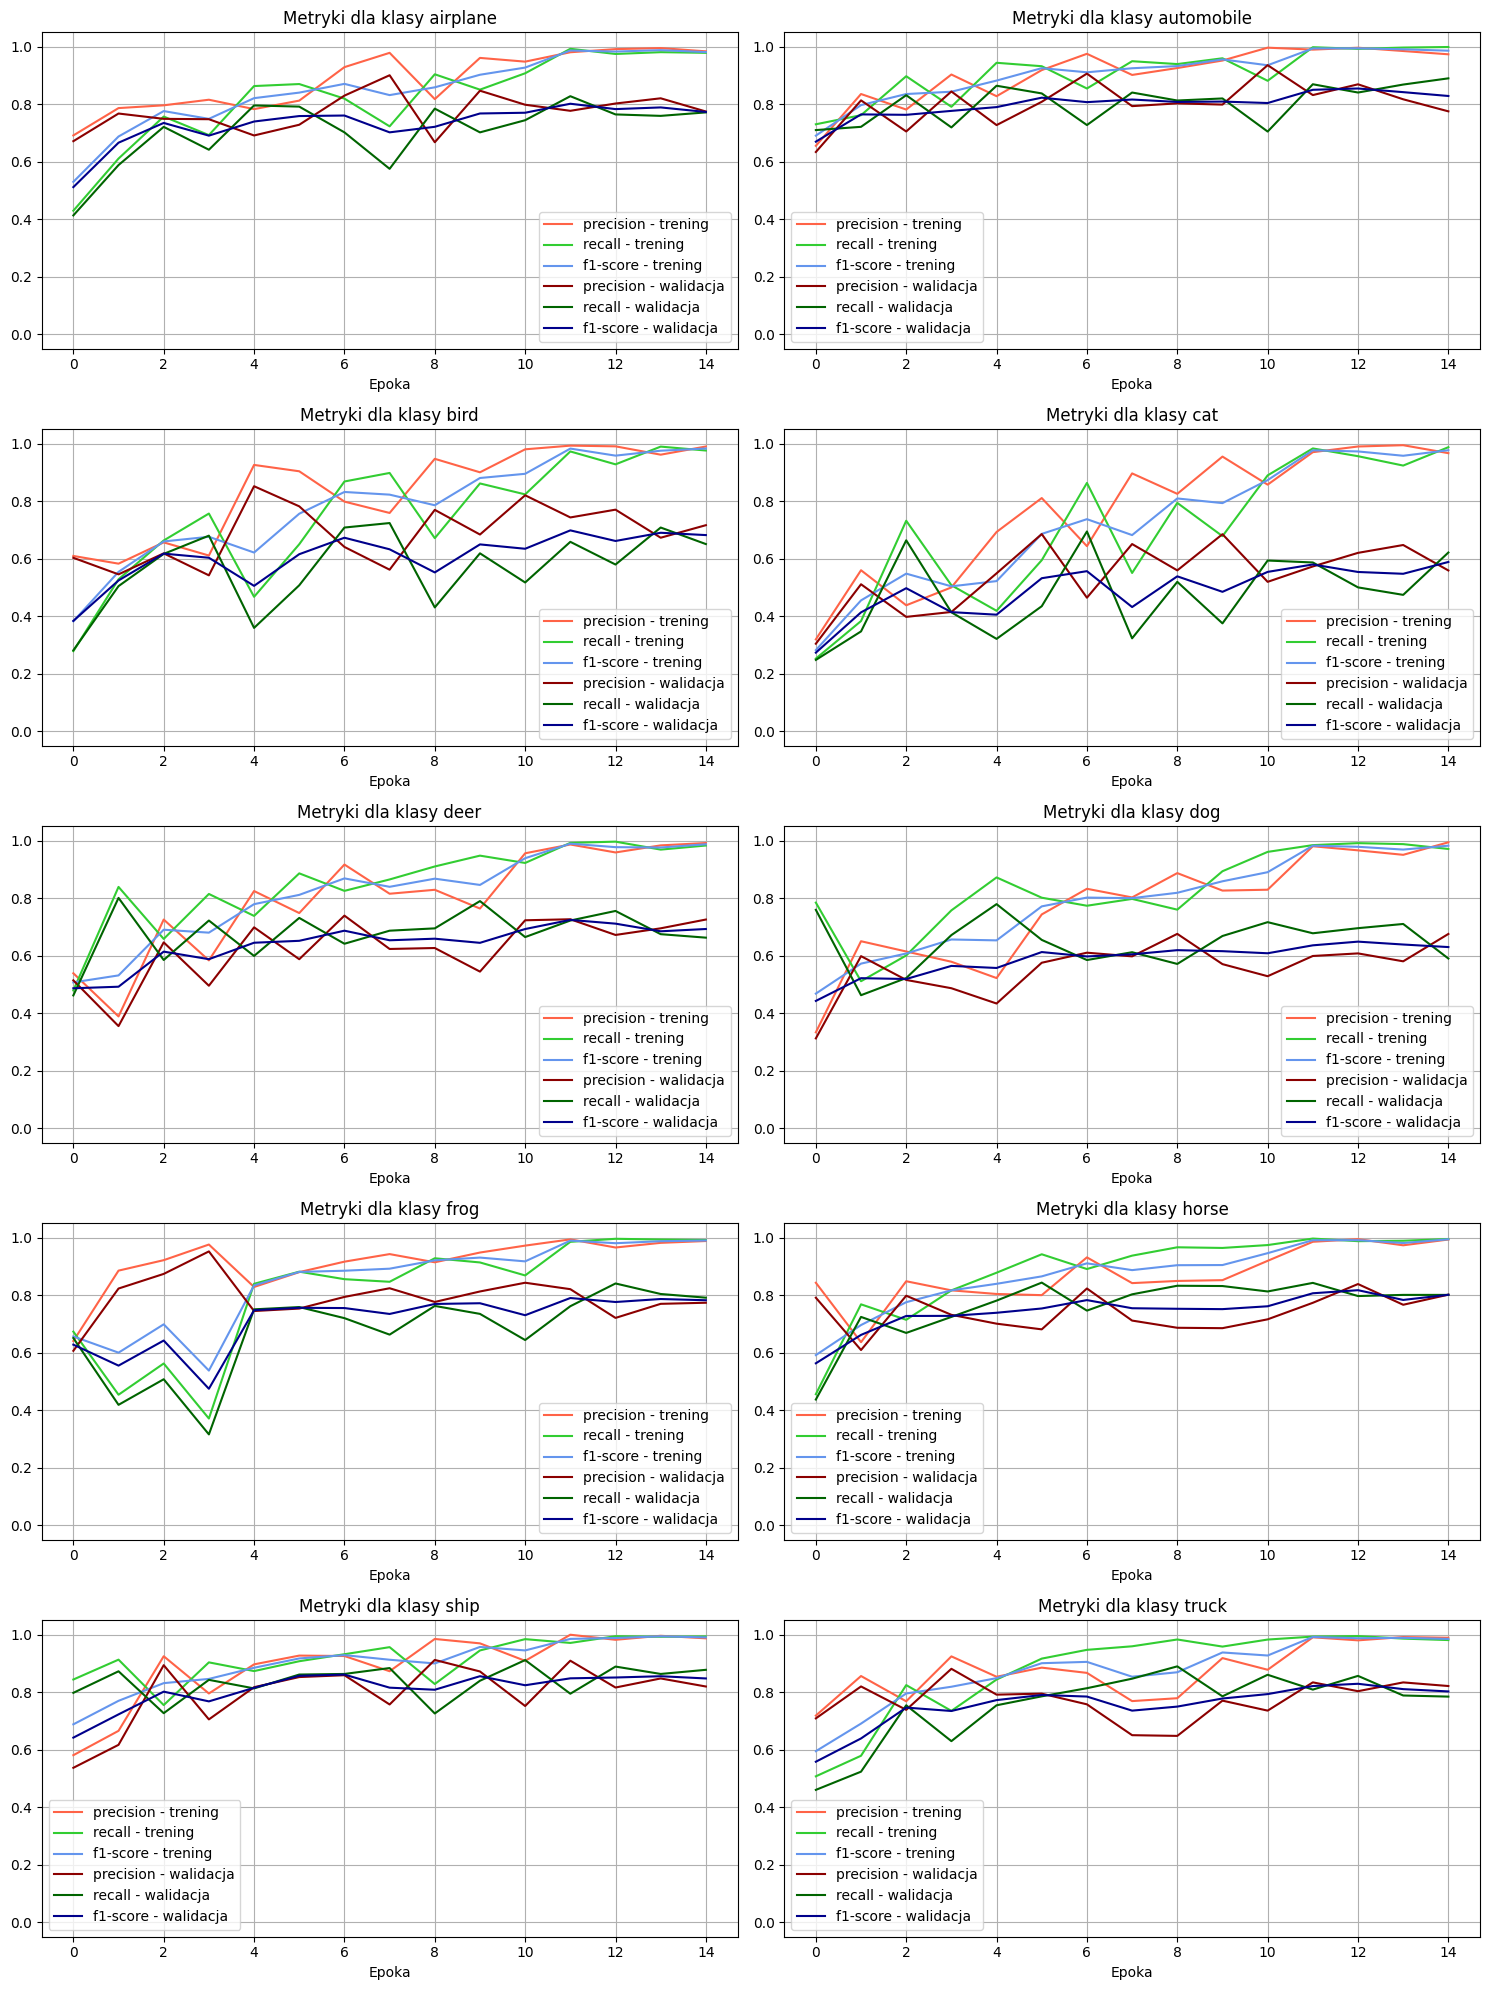

In [ ]:
epochs_num = 15
model = resnet34() # model bez pretrenowanych wag
model = prepare_model_for_training(model, modules_to_unfreeze_names=[name for name, _ in model.named_children()])
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), weight_decay=0.0001)

trainer = m.TrainingClass(model, device, nn.CrossEntropyLoss(), optimizer, early_stopping=True, patience=15)
ts_loss4, tr_losses4, val_losses4, tr_metrics4, val_metrics4, tr_accuracies4, val_accuracies4 = trainer.training_loop(epochs_num, "resnet-4", trainloader, validationloader, testloader)

m.create_loss_and_accuracy_plot(tr_losses4, val_losses4, tr_accuracies4, val_accuracies4)
m.create_metrics_plot(tr_metrics4, val_metrics4)

Wykorzystanie wyłącznie samej architektury bez pretrenowanych wag zwróciło gorsze wyniki zarówno dla zbioru walidacyjnego, jak i w niewielkim stopniu również treningowego. Wygląda na to, że transfer wiedzy w poprzednim eksperymencie okazał się kluczowy do optymalizacji wyników, jako że problem na którym pierwotnie trenowana była sieć resnet-34 jest podobny do tego w tym notatniku, tylko tutaj jest na mniejszą skalę - 170MB danych z CIFAR10 w porównaniu do imagenet o rozmiarze liczonym w gigabajtach.

# Podsumowanie

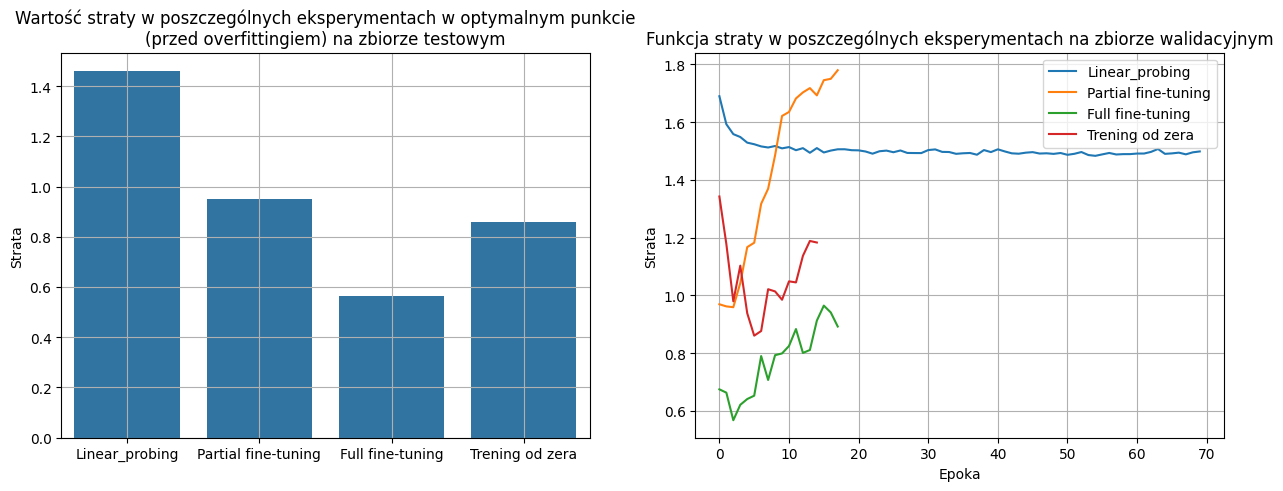

In [ ]:
plt.figure(figsize=(15, 5))
# pierwsza wizualizacja
plt.subplot(1, 2, 1)
plt.title('Wartość straty w poszczególnych eksperymentach w optymalnym punkcie\n(przed overfittingiem) na zbiorze testowym')
sns.barplot(x=['Linear_probing', 'Partial fine-tuning', 'Full fine-tuning', 'Trening od zera'], y=[ts_loss1, ts_loss2, ts_loss3, ts_loss4])
plt.ylabel('Strata')
plt.grid()
# druga wizualizacja
plt.subplot(1, 2, 2)
plt.title('Funkcja straty w poszczególnych eksperymentach na zbiorze walidacyjnym')
plt.plot(val_losses1, label='Linear_probing')
plt.plot(val_losses2, label='Partial fine-tuning')
plt.plot(val_losses3, label='Full fine-tuning')
plt.plot(val_losses4, label='Trening od zera')
plt.grid()
plt.ylabel('Strata')
plt.xlabel('Epoka')
plt.legend()
plt.show()

Powyższe wizualizacje wskazują, że model najlepiej sobie radził podczas eksperymentu, gdzie wszystkie parametry zostały odmrożone oraz początkowe wagi nie były losowe a zaczerpnięte z pretrenowanego modelu, co okazało się skuteczne najpewniej z powodu podobieństwa problemu klasyfikacji obrazów imagenet oraz klasyfikacji na cifar10.

W pierwszym eksperymencie dynamika uczenia była najmniejsza, jako że trenowalna była tylko ostatnia warstwa, która stanowi niewielką część całego modelu.

Kolejne eksperymenty z odmrażaniem coraz to większej części pretrenowanego modelu dawały coraz lepsze wyniki (w optymalnym momencie), jednak kosztem wystąpienia później dość silnego overfittingu. Możliwe że mocniejsza redukcja learning rate ustabilizowałaby uczenie, jako że autorzy artykułu dzielili ten współczynnik przez 10 a ja tylko przez 2.

Ostatni eksperyment pokazuje natomiast istotę użycia wag z pretrenowanego modelu. Bez nich, w początkowej części treningu wyniki są zauważalnie gorsze niż podczas fine-tuning'u.

Trudno porównać te wyniki z poprzednim notatnikiem, gdyż tutaj zastosowałem zbiór CIFAR10 natomiast na modelach CNN użyłem mniej złożonego zbioru FashionMNIST, jednak patrząc na to, że zbiór MNIST składa się z 1-kanałowych obrazów 28x28 a sam zbiór waży 30MB i wszystkie obrazy są z tych samych lub bardzo podobnych ujęć, a CIFAR10 zawiera 3-kanałowe obrazy 32x32, waży 170MB oraz zawiera obrazy z różnych perspektyw to uzyskanie niewiele gorszych wyników w porównaniu z poprzednim notatnikiem świadczy raczej o korzyści ze stosowania rachitektury ResNet. W tym notatniku (po zbiorze walidacyjnym) strata pomiędzy poszczególnymi eksperymentami wahała się między 0.5 ~ 1.5 w porównaniu do 0.3 ~ 1.1 w notatniku z CNN, natomiast dokładność wahała się między 49% ~ 85% w porównaniu do 65% ~ 91% w notatniku z CNN.